# Notebook 1 — Exploratory Data Analysis

Obiettivo: comprendere le distribuzioni dei sensori, la durata del ciclo di vita dei motori e identificare i sensori a varianza costante da rimuovere prima del training.

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys
# sys.path.append necessario per importare il modulo src/ dall'interno della cartella notebooks/
sys.path.append('..')
from src.preprocessing import load_raw, COLUMNS, DROP_SENSORS

sns.set_style('whitegrid')
DATA_DIR = '../data/raw'

## 1. Caricamento dei dataset

CMAPSS contiene 4 sotto-dataset con diversa complessità:
- **FD001/FD003**: 1 condizione operativa → normalizzazione MinMax globale
- **FD002/FD004**: 6 condizioni operative → normalizzazione cluster-based per regime

Ogni file ha 26 colonne: ID motore, ciclo operativo, **3 impostazioni operative** e 21 sensori.

Le **impostazioni operative** (setting1, setting2, setting3) descrivono le condizioni di volo:
- `setting1` → quota di volo (ft)
- `setting2` → numero di Mach
- `setting3` → angolo del throttle (TRA, %)

In FD001/FD003 questi valori sono quasi costanti (1 regime di volo). In FD002/FD004 variano tra i cicli (6 profili di volo diversi).

Carico solo i file di **train**: i file di test non contengono le etichette RUL (fornite separatamente in `RUL_FDxxx.txt`).

In [22]:
# Carico solo il train: il test non ha etichette RUL interne
datasets = {}
for fd in ['FD001', 'FD002', 'FD003', 'FD004']:
    datasets[fd] = load_raw(f'{DATA_DIR}/train_{fd}.txt')
    print(f'{fd}: {datasets[fd].shape}')

FD001: (20631, 19)
FD002: (53759, 19)
FD003: (24720, 19)
FD004: (61249, 19)


## 2. Distribuzione del ciclo di vita dei motori

Per ogni motore calcolo il numero massimo di cicli operativi prima del guasto.

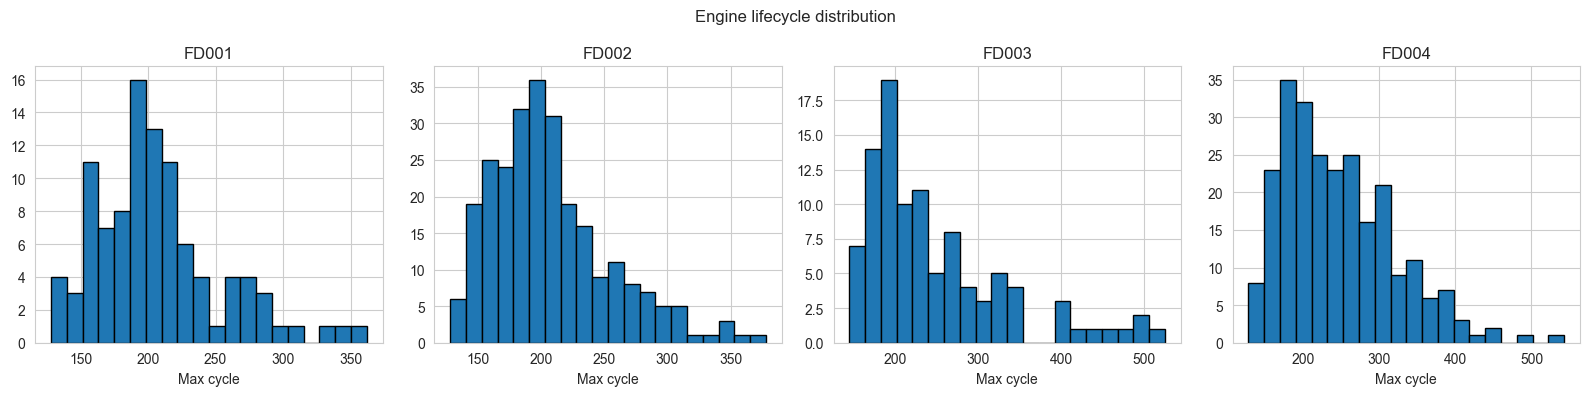

In [23]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for i, (fd, df) in enumerate(datasets.items()):
    # max cycle per motore = durata vita effettiva (cicli totali fino al guasto)
    life = df.groupby('engine_id')['cycle'].max()
    axes[i].hist(life, bins=20, edgecolor='black')
    axes[i].set_title(fd)
    axes[i].set_xlabel('Max cycle')
# FD003 e FD004 mostrano code più lunghe → alta variabilità inter-motore
plt.suptitle('Engine lifecycle distribution')
plt.tight_layout()
plt.savefig('../plots/01_lifecycle_distribution.png', dpi=150)
plt.show()

### Cosa mostra questo grafico

Questo grafico mostra la distribuzione della durata di vita dei motori nei quattro sotto-dataset. Ogni barra indica quanti motori hanno raggiunto una certa durata massima prima del guasto: sull'asse X c'è il numero di cicli vissuti, sull'asse Y quanti motori hanno avuto quella durata.

- La prima cosa che si nota è che quasi tutti i motori vivono ben oltre 125 cicli — la maggior parte si concentra tra 150 e 250 cicli, con alcuni che arrivano fino a 500 in FD003 e FD004. Questo giustifica direttamente la scelta del cap a 125: se quasi nessun motore si rompe prima dei 125 cicli, vuol dire che in quella fase iniziale i sensori non mostrano ancora segni di degrado distinguibili. Non avrebbe senso chiedere al modello di predire RUL=350 o RUL=280 quando i dati dei sensori sono praticamente identici in entrambi i casi.

- La seconda cosa interessante è la differenza tra i dataset. FD001 e FD002 hanno distribuzioni più strette e concentrate attorno ai 200 cicli — i motori sono più omogenei tra loro. FD003 e FD004 hanno distribuzioni molto più larghe con una coda lunga verso destra: alcuni motori durano il doppio della media. Questa maggiore variabilità inter-motore contribuisce a rendere FD003 e FD004 più difficili da modellare.

- Dal ciclo 1 al ciclo 175 circa, i sensori sono sostanzialmente piatti — il motore è sano e non mostra variazioni sistematiche. Non riesci a capire se mancano 299 cicli o 200 cicli al guasto, perché i dati sono praticamente identici.
Dal ciclo 175 in poi i sensori iniziano a deviare — s2 inizia a salire, s14 inizia a scendere, il trend diventa visibile. Da qui in poi il modello può effettivamente imparare qualcosa di utile.
Quel momento in cui i sensori iniziano a deviare corrisponde a circa 125 cicli prima del guasto. Quindi il degrado esiste e si vede, ma solo negli ultimi ~125 cicli.

- Allora cosa fa il cap
Il cap dice al modello: tutto quello che succede prima che manchino 125 cicli trattalo come uguale, assegna label 125 a tutti quei cicli. Non perché non ci sia degrado, ma perché il segnale non è ancora abbastanza informativo da distinguere RUL=299 da RUL=200.
Il degrado vero e proprio — quello visibile nei grafici dei sensori che salgono o scendono — avviene tutto negli ultimi 125 cicli. È lì che il modello impara. Il cap semplicemente dice: concentrati su quella fase, non sprecare capacità a cercare di distinguere cicli in cui i dati sono identici.

## 3. Selezione dei sensori: analisi della varianza

Calcolo la varianza di ogni sensore per identificare quelli che non cambiano mai durante la vita del motore. Un sensore con varianza zero è costante → non può portare alcuna informazione sul degrado.

**Attenzione**: varianza bassa non significa automaticamente sensore inutile. Sensori come `s8`, `s13`, `s15` hanno varianza piccola ma mostrano comunque un trend correlato al degrado, visibile nell'analisi temporale successiva. La selezione finale (`DROP_SENSORS`) segue la scelta standard della letteratura (Zheng et al., 2017), confermata visivamente dai trend.

In [24]:
df = datasets['FD001']
sensor_cols = [c for c in df.columns if c.startswith('s')]
# Calcolo varianza di ogni sensore su tutto il dataset e ordino in senso crescente
variance = df[sensor_cols].var().sort_values()

print('Varianza di tutti i sensori (ordinata dal più basso):')
print(variance.round(5))
print()
# I sensori rimossi seguono la scelta della letteratura (Zheng et al., 2017):
# sono quelli con varianza esattamente o quasi zero su tutti i dataset CMAPSS
print('Sensori rimossi (DROP_SENSORS):', DROP_SENSORS)
print('Sensori mantenuti nonostante varianza bassa (s8, s13, s15): mostrano trend di degrado')

Varianza di tutti i sensori (ordinata dal più basso):
setting3      0.00000
setting2      0.00000
setting1      0.00000
s15           0.00141
s8            0.00504
s13           0.00517
s21           0.01172
s20           0.03267
s11           0.07134
s2            0.25005
s12           0.54399
s7            0.78339
s17           2.39867
s3           37.59099
s4           81.01089
s14         363.90049
s9          487.65357
dtype: float64

Sensori rimossi (DROP_SENSORS): ['s1', 's5', 's6', 's10', 's16', 's18', 's19']
Sensori mantenuti nonostante varianza bassa (s8, s13, s15): mostrano trend di degrado


### Cosa mostrano questi risultati

I sensori `s1, s5, s6, s10, s16, s18, s19` hanno varianza **esattamente zero**: il loro valore non cambia mai, per nessun motore, in nessun ciclo. Sono sensori che misurano grandezze fisiche non influenzate dal tipo di guasto simulato in CMAPSS e vengono rimossi automaticamente in `load_raw()` prima di qualsiasi elaborazione.

Compaiono anche i **settings** (setting1, setting2, setting3) con varianza quasi nulla: in FD001 c'è una sola condizione operativa, quindi quota, Mach e throttle variano pochissimo tra i cicli. Vengono comunque mantenuti perché in FD002/FD004 (6 condizioni) la loro varianza è alta e sono fondamentali per identificare il regime operativo tramite KMeans.

**Perché s8, s13, s15 rimangono?** La loro varianza è bassa ma non zero: variano di poco in valore assoluto, ma quel piccolo segnale è correlato al processo di degrado. Rimuoverli peggiora le prestazioni — questo è un risultato documentato in letteratura e confermato anche visivamente nel grafico dei trend che segue.

## 4. Andamento dei sensori nel tempo (Motore 1, FD001)

Per capire quali sensori "raccontano" il degrado del motore, guardo come cambiano nel tempo.
Disegno un pannello per ogni sensore mantenuto, su un solo motore (il n. 1, ~200 cicli di vita):
un motore basta perché l'andamento è rappresentativo di tutti gli altri.

L'idea da tenere a mente: man mano che il motore si consuma, alcune grandezze fisiche
salgono e altre scendono in modo regolare. Sono proprio questi trend che la rete dovrà imparare
a riconoscere per stimare quanto tempo manca al guasto.

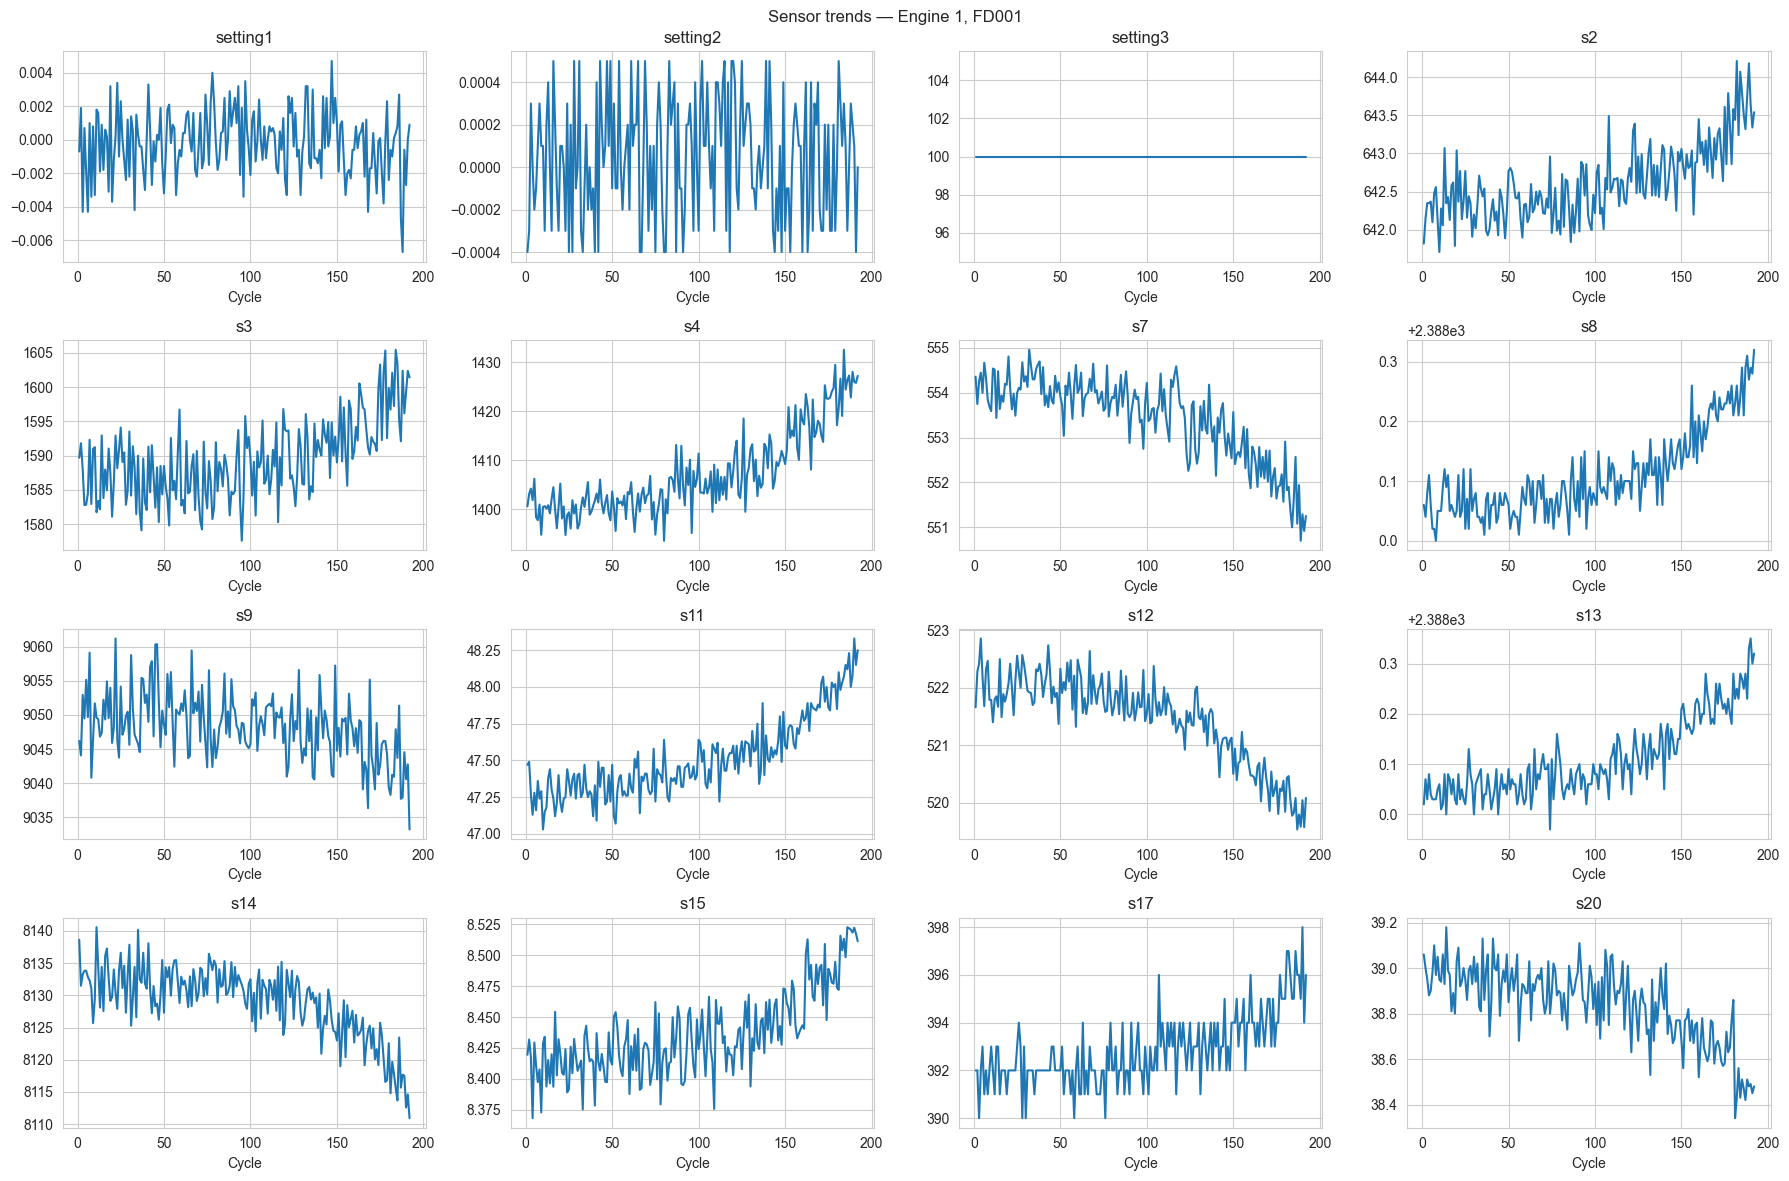

In [25]:
# Filtro il motore 1 per l'analisi visiva
engine = df[df['engine_id'] == 1]
# Escludo i sensori costanti già identificati
keep_sensors = [c for c in sensor_cols if c not in DROP_SENSORS]

fig, axes = plt.subplots(4, 4, figsize=(18, 12))
for ax, s in zip(axes.flatten(), keep_sensors):
    ax.plot(engine['cycle'], engine[s])
    ax.set_title(s)
    ax.set_xlabel('Cycle')
plt.suptitle('Sensor trends — Engine 1, FD001')
plt.tight_layout()
plt.savefig('../plots/01_sensor_trends.png', dpi=150)
plt.show()

### Cosa mostra questo grafico

Ogni pannello è un sensore: sull'asse x i cicli di vita del motore, sull'asse y il valore misurato.
Leggendo i 16 pannelli si vedono **quattro comportamenti**.

**1. Sensori che salgono con il degrado** — `s2`, `s3`, `s4`, `s11`, `s15`, `s17`  
Crescono in modo regolare verso fine vita. Sono i più informativi: il valore aumenta perché il
motore si surriscalda e perde efficienza. Da notare `s15`: varia poco in valore assoluto, ma
**sale in modo sistematico** → conferma perché lo teniamo nonostante la varianza bassa.

**2. Sensori che scendono con il degrado** — `s7`, `s12`, `s14`, `s20`  
Speculari ai primi: calano in modo regolare verso fine vita. Anche questi sono ottimi predittori,
solo con segno opposto.

**3. Sensori rumorosi ma utili** — `s8`, `s9`, `s13`  
Saltano molto da un ciclo all'altro, ma sotto al rumore c'è un trend debole. Da soli dicono poco;
diventano utili quando la rete li guarda dentro una finestra di più cicli.

**4. Le impostazioni operative (settings)** — in FD001 non aiutano:  
`setting1` e `setting2` sono rumore puro, `setting3` è una linea piatta. Normale: qui c'è una sola
condizione di volo. In FD002/FD004, invece, i settings assumono 6 valori distinti e diventano la
chiave per riconoscere il regime operativo (clustering).

---

**Perché serve la finestra temporale:** un singolo istante non basta, soprattutto per i sensori
rumorosi. Una finestra di 30 cicli dà alla rete abbastanza contesto per distinguere il rumore dal
vero trend di degrado.